<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Laberinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laberinto**

**Objetivo**

**Ejercicio**
En ausencia de aprendizaje, una rata en un laberinto se mueve aleatoriamente. Si hay $k$ formas de abandonar un laberinto, elije una salida con probabilidad $1/k$. ¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

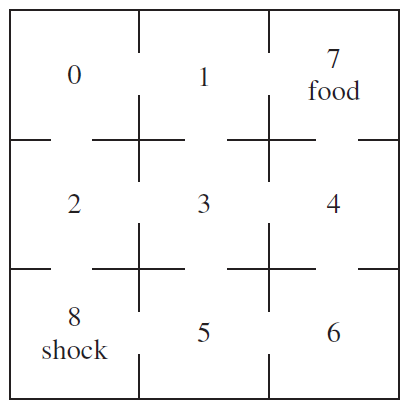




Definimos los estados:



*   Estado 0: punto de incio
*   Estado 1: punto de unión de $A(PA)$
*   Estado 2: punto de inicio
*   Estado 3:
*   Estado 4:



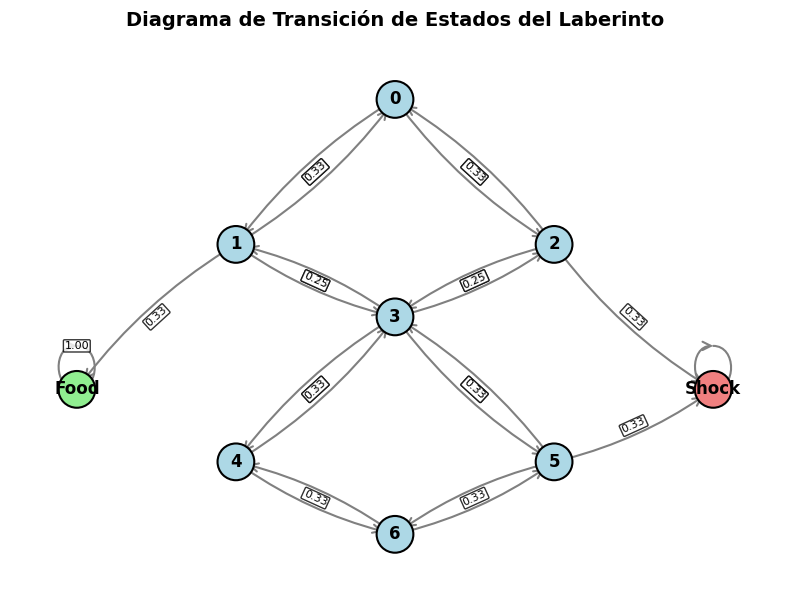

In [ ]:
# Configurar la visualización
plt.figure(figsize=(8, 6))

# Crear el grafo (Dirigido, ya que las transiciones tienen dirección)
G = nx.DiGraph() # Initialize the graph object

# Definir los nodos del laberinto (del 0 al 8)
# Los estados 7 (Comida) y 8 (Electroshock) son absorbentes
nodes = list(range(9))
G.add_nodes_from(nodes)

# Añadir aristas con las probabilidades de transición
# (u, v, probability)
# Estado 0 (inicio)
G.add_edge(0, 1, label=matriz[0,1])
G.add_edge(0, 2, label=matriz[0,2])

# Estado 1 (Junction A)
G.add_edge(1, 0, label=matriz[1,0])
G.add_edge(1, 3, label=matriz[1,3])
G.add_edge(1, 7, label=matriz[1,7]) # A comida

# Estado 2 (Junction B)
G.add_edge(2, 0, label=matriz[2,0])
G.add_edge(2, 3, label=matriz[2,3])
G.add_edge(2, 8, label=matriz[2,8]) # A electroshock

# Estado 3 (Junction C)
G.add_edge(3, 1, label=matriz[3,1])
G.add_edge(3, 2, label=matriz[3,2])
G.add_edge(3, 4, label=matriz[3,4])
G.add_edge(3, 5, label=matriz[3,5])

# Estado 4 (Junction D)
G.add_edge(4, 3, label=matriz[4,3])
G.add_edge(4, 6, label=matriz[4,6])

# Estado 5 (Junction E)
G.add_edge(5, 3, label=matriz[5,3])
G.add_edge(5, 6, label=matriz[5,6])
G.add_edge(5, 8, label=matriz[5,8]) # A electroshock

# Estado 6 (Junction F)
G.add_edge(6, 4, label=matriz[6,4])
G.add_edge(6, 5, label=matriz[6,5])

# Estados absorbentes (ya definidos en la matriz, pero se pueden añadir para claridad visual)
G.add_edge(7, 7, label=matriz[7,7]) # Comida se mantiene en comida
G.add_edge(8, 8, label=matriz[8,8]) # Electroshock se mantiene en electroshock

# Posición de los nodos para una visualización clara (ajusta según la imagen del laberinto)
pos = {
    0: (0, 3), # Inicio
    1: (-1, 2), # PA
    2: (1, 2), # PB
    3: (0, 1.5), # PC
    4: (-1, 0.5), # PD
    5: (1, 0.5), # PE
    6: (0, 0), # PF
    7: (-2, 1), # Comida
    8: (2, 1)  # Electroshock
}

# Dibujar nodos
nx.draw_networkx_nodes(G, pos,
                      node_color=['lightgreen' if n == 7 else 'lightcoral' if n == 8 else 'lightblue' for n in G.nodes()],
                      node_size=700,
                      edgecolors='black',
                      linewidths=1.5)

# Dibujar aristas con flechas simples ->
nx.draw_networkx_edges(G, pos,
                      arrows=True,
                      arrowstyle='->',
                      arrowsize=15,
                      width=1.5,
                      edge_color='gray',
                      connectionstyle='arc3,rad=0.1')

# Etiquetas de los nodos
nx.draw_networkx_labels(G, pos,
                       labels={n: str(n) if n not in [7,8] else ('Food' if n==7 else 'Shock') for n in G.nodes()},
                       font_size=12,
                       font_weight='bold')

# Etiquetas de las aristas (probabilidades)
edge_labels = {(u, v): f'{d["label"]:.2f}' for u, v, d in G.edges(data=True) if d['label'] > 0}
nx.draw_networkx_edge_labels(G, pos,
                            edge_labels=edge_labels,
                            font_size=8,
                            bbox=dict(boxstyle='round,pad=0.1',
                                     facecolor='white',
                                     alpha=0.8))

plt.title('Diagrama de Transición de Estados del Laberinto', fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

Obteniendio la matriz  de transición


In [ ]:
import numpy as np
from sympy import Matrix , init_printing
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:

matriz = sp.Matrix([
        [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],
    [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],
    [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],
    [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 1/2, 0, 0, 1/2, 0, 0, 0]
])

print("Matriz de Transición de P:")

Matriz de Transición de P:


In [ ]:
matriz

Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0,                 0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0, 0.333333333333333,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0,                 0, 0.333333333333333],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0,                 0,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333, 0.333333333333333,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333,                 0, 0.333333333333333],
[                0,    0,    0,                 0,    0,    0,                 1,                 0,                 0],
[                0,    0,    0,                 0,    0,    0,                 0,                 1,                 0],
[                0,    

¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

Para ello, procedamos a utilizar las ecuaciones de balance  $π=(p_0)$ hasta $p_8$

In [ ]:
# Definimos variables para p[0..8]
p0, p1, p2, p3, p4, p5, p6, p7, p8 = sp.symbols('p0 p1 p2 p3 p4 p5 p6 p7 p8')

# Ecuaciones
eq0 = sp.Eq(p0, (p1 + p2) / 2) # grado 2
eq1 = sp.Eq(p1, (p0 + 1 + p3) / 3) # p[7] = 1
eq2 = sp.Eq(p2, (p0 + p3 + p8) / 3) # grado 3
eq3 = sp.Eq(p3, (p1 + p2 + p4 + p5) / 4)# grado 4
eq4 = sp.Eq(p4, (1 + p3 + 0) / 3) # p[7] = 1, p[6] = 0
eq5 = sp.Eq(p5, (p8 + p3 + 0) / 3) # p[6] = 0
eq6 = sp.Eq(p6, 0) # p[7] = 1
eq7= sp.Eq(p7, 1) # p[6] = 0
eq8 = sp.Eq(p8, (p2 + p5) / 2) # grado 2

# Resolver
sol = sp.solve([eq0, eq1, eq2, eq3, eq4, eq5, eq6, eq7,  eq8],
               [p0, p1, p2, p3, p4, p5,p6, p7,  p8])

print("Solución:")
for var, val in sol.items():
    print(f"{var} = {val}")

# Si queremos la respuesta desde el nodo inicial (0):
print("\nProbabilidad desde nodo 0 (inicio):", sol[p0])


Solución:
p0 = 3/5
p1 = 7/10
p2 = 1/2
p3 = 1/2
p4 = 1/2
p5 = 3/10
p6 = 0
p7 = 1
p8 = 2/5

Probabilidad desde nodo 0 (inicio): 3/5


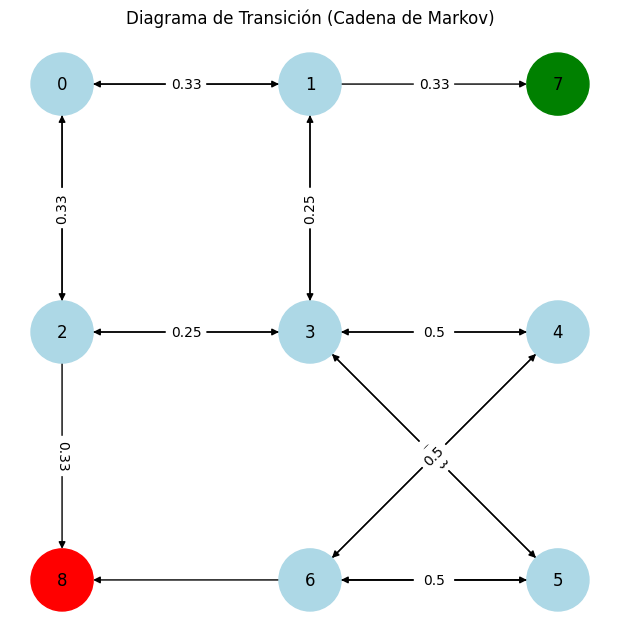

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Estados y vecinos (tu mismo modelo)
neighbors = {
    0:[1,2],
    1:[0,3,7],
    2:[0,3,8],
    3:[1,2,4,5],
    4:[3,6],
    5:[3,6,8],
    6:[4,5],
    7:[],  # absorbente (food)
    8:[]   # absorbente (shock)
}

# Crear grafo dirigido
G = nx.DiGraph()

# Agregar aristas con probabilidades
for s, nbs in neighbors.items():
    k = len(nbs)
    for nb in nbs:
        G.add_edge(s, nb, weight=round(1/k, 2))

# Posiciones (para que se vea como tu cuadrícula)
pos = {
    0:(0,2), 1:(1,2), 2:(0,1),
    3:(1,1), 4:(2,1), 5:(2,0),
    6:(1,0), 7:(2,2), 8:(0,0)
}

# Colores (absorventes distintos)
colors = []
for node in G.nodes():
    if node == 7:
        colors.append("green")   # comida
    elif node == 8:
        colors.append("red")     # shock
    else:
        colors.append("lightblue")

# Dibujar nodos y aristas
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=12)

# Etiquetas de probabilidad
edge_labels = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Diagrama de Transición (Cadena de Markov)")
plt.show()